### IMPORTING NECESSARY LIBRARIES

In [3]:
from google.colab import files
uploaded = files.upload()
!apt-get install -y fonts-liberation
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math


Saving benchmarking.tsv to benchmarking.tsv
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


### Functions

In [36]:
def compute_matrix(frag_15:pd.Series,output_arrayname:str) -> np.ndarray:
  '''Compute the position-specific weight matrix (PSWM) from a given FASTA file and save it as a .npz file.'''
  swissprot = np.array([0.0825, 0.0393, 0.0964, 0.0665,0.0552, 0.0671, 0.0579, 0.0536, 0.0406, 0.0707, 0.0410, 0.0100,
                      0.0546, 0.0227, 0.0386, 0.0292, 0.0138, 0.0590, 0.0474, 0.0685])
  alphabet = "AQLSREKTNGMWDHFYCIPV"
  pswm = np.ones((len(alphabet),len(frag_15[0])))
  seq_number = 0
  for frag in frag_15:
      seq_number += 1
      frag_m = np.zeros((len(alphabet),len(frag)))
      col = 0
      for res in frag:
        if res != "X":
          index = alphabet.index(res)
          frag_m[index][col] += 1
          col += 1
      pswm += frag_m
  pswm = (pswm/(seq_number+20))
  pswm = pswm / swissprot.reshape(-1, 1)
  pswm = np.log2(pswm)
  np.savez(output_arrayname, pswm)
  return pswm

In [37]:
def compute_score (sequence,  window, pswm, alphabet = "AQLSREKTNGMWDHFYCIPV"):
    seq_len = len(sequence)
    scores = np.zeros(seq_len - window + 1)

    for pos in range(seq_len - window + 1):
        window_seq = sequence[pos:pos+window]
        score = 0.0
        for i, res in enumerate(window_seq):
            if res != "X":
                idx = alphabet.find(res)
                score += pswm[idx, i]
        scores[pos] = score

    return scores.max()


In [38]:
def compute_confusion_matrix(preds, labels):
  TP, TN, FP, FN = 0,0,0,0
  for i in range(len(preds)):
    if preds[i] == labels[i] and labels[i] == 0:
      TN += 1
    elif preds[i] == labels[i] and labels[i] == 1:
      TP += 1
    elif preds[i] != labels[i] and labels[i] == 0:
      FP += 1
    elif preds[i] != labels[i] and labels[i] == 1:
      FN +=1
  return TP, FP, FN, TN

In [39]:
def accuracy(TP, FP, FN, TN):
    return (TP + TN) / (TP + TN + FP + FN)

In [40]:
def mcc(TP, FP, FN, TN):
    numerator = (TP * TN) - (FP * FN)
    denominator = math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    return numerator / denominator if denominator != 0 else 0.0

In [41]:
def recall(TP, FP, FN, TN):
    return TP / (TP + FN) if (TP + FN) != 0 else 0.0

In [42]:
def precision(TP, FP, FN, TN):
    return TP / (TP + FP) if (TP + FP) != 0 else 0.0
print(precision(TP, FP, FN, TN))
prec = precision(TP, FP, FN, TN)

0.6613545816733067


In [43]:
def f1_score(prec, rec):
    return 2 * (prec * rec) / (prec + rec) if (prec + rec) != 0 else 0.0

### Setting Seaborn Theme

In [5]:
#Set theme in Seaborn
sns.set_theme()
mpl.rcParams['font.family'] = ['Liberation Serif', 'serif']
mpl.rcParams['font.serif'] = ['Liberation Serif']
mpl.rcParams['axes.unicode_minus'] = False  # avoid minus rendering issues
sns.set_theme(context='notebook', style='white', palette='viridis', font='Liberation Serif', font_scale=1.1)

### DATABASE IMPORT

In [58]:
training = pd.read_csv("Performance.tsv", sep = "\t")
benchmarking = pd.read_csv("benchmarking.tsv", sep = "\t")

   Unnamed: 0 UniProt_ID  Class  Label  \
0           0     P52798      1      1   
1           1     P17948      1      1   
2           2     Q8WWA0      1      1   
3           3     O75629      1      1   
4           4     P19069      1      1   

                                             Frag_90            SP_15  \
0  MRLLPLLRTVLWAAFLGSPLRGGSSLRHVVYWNSSNPRLLRGDAVV...  AAFLGSPLRGGSSLR   
1  MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...  LLSCLLLTGSSSGSK   
2  MNQLSFLLFLIATTRGWSTDEANTYFKEWTCSSSPSLPRSCKEIKD...  FLLFLIATTRGWSTD   
3  MAGLSRGSARALLAALLASTLLALLVSPARGRGGRDHGDWDEASRL...  STLLALLVSPARGRG   
4  MRLLWGLLWAFGLFASSLQKPRLLLFSPSVVNLGVPLSVGVQLQDA...  LLWAFGLFASSLQKP   

   Prediction  Cleavage  Seq_Length  TM_Helix  
0           0        25         201     False  
1           0        26        1338     False  
2           0        18         313     False  
3           0        31         220     False  
4           0        19        1742     False  
   Unnamed: 0 UniPro

# PERFORMANCE EVALUATION

In [34]:
# Building the matrix on the training data:
sequences = training[training['Class'] == 1]
sequences = sequences['SP_15']
pswm = compute_matrix(sequences, "PSWM_eval")

# Testing on benchmarking using averaged threshold:
th = 8.8089

sequences = benchmarking['Frag_90'].to_numpy()
Y = benchmarking['Class'].to_numpy()
y = np.zeros(len(sequences))

X = np.zeros(len(sequences))
for j in range(len(sequences)):
        X[j] = compute_score(sequences[j], 15, pswm)

y = np.where(X >= th, 1, 0)

TP, FP, FN, TN = compute_confusion_matrix(y, Y)

acc = accuracy(TP, FP, FN, TN)
rec = recall(TP, FP, FN, TN)
prec = precision(TP, FP, FN, TN)
f1 = f1_score(prec, rec)
MCC = mcc(TP, FP, FN, TN)

metrics = pd.DataFrame([{
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'MCC': MCC,
        'Threshold': th}])

   Accuracy  Precision    Recall  F1-score       MCC  Threshold
0  0.931206   0.661355  0.757991  0.706383  0.669618     8.8089


### Saving Results

In [59]:
benchmarking['Prediction'] = y
print(benchmarking['Prediction'].head(100))
benchmarking.to_csv("results_VH.tsv", sep = "\t", index = False)

0     1
1     1
2     1
3     1
4     0
     ..
95    1
96    0
97    1
98    1
99    1
Name: Prediction, Length: 100, dtype: int64


### Plotting Results

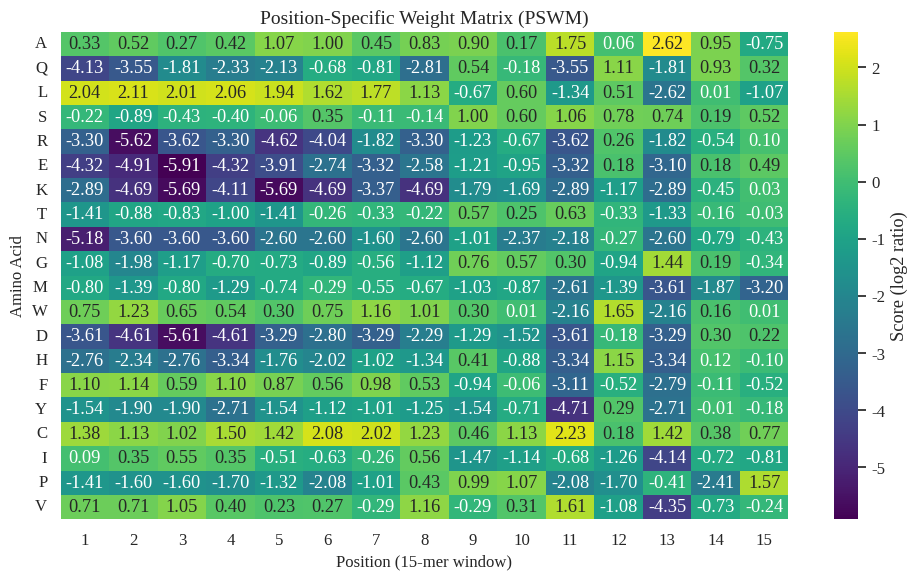

<Figure size 1000x600 with 0 Axes>

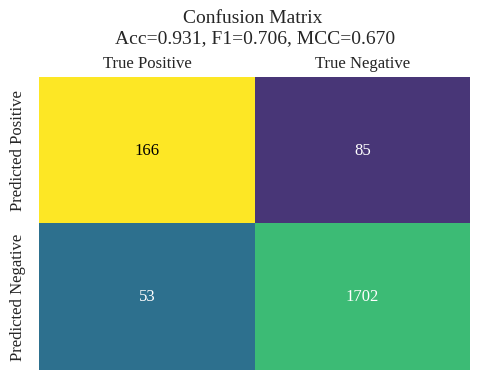

In [48]:
#Create the PSWM heatmap
alphabet = list("AQLSREKTNGMWDHFYCIPV")
plt.figure(figsize=(10, 6))
sns.heatmap(pswm,cmap="viridis",annot=True,fmt=".2f",yticklabels=alphabet,xticklabels=range(1, pswm.shape[1] + 1),cbar_kws={'label': 'Score (log2 ratio)'})

plt.title(f"Position-Specific Weight Matrix (PSWM)", fontsize=14)
plt.xlabel("Position (15-mer window)", fontsize=12)
plt.ylabel("Amino Acid", fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
alphabet = list("AQLSREKTNGMWDHFYCIPV")
plt.figure(figsize=(10, 6))
sns.heatmap(pswm,cmap="viridis",annot=True,fmt=".2f",yticklabels=alphabet,xticklabels=range(1, pswm.shape[1] + 1),cbar_kws={'label': 'Score (log2 ratio)'})

plt.title(f"Position-Specific Weight Matrix (PSWM)", fontsize=14)
plt.xlabel("Position (15-mer window)", fontsize=12)
plt.ylabel("Amino Acid", fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"PSWM.png", dpi=1000, format="png",bbox_inches="tight",pad_inches=0.2)
plt.clf()

# Confusion Matrix
plot_cm = np.array([[TP, FP],
                        [FN, TN]])

cell_colors = np.array([['#fde725ff', '#483677ff'],
                            ['#2d708eff', '#3cbb75ff']])

fig, ax = plt.subplots(figsize=(5, 4))

for r in range(2):
  for c in range(2):
    ax.add_patch(plt.Rectangle((c, 1-r), 1, 1, color=cell_colors[r, c], edgecolor=None, linewidth=0))
    text_color = 'black' if (r, c) == (0, 0) else 'white'
    ax.text(c + 0.5, 1.5 - r, plot_cm[r, c],
                    ha='center', va='center', fontsize=12,
                    fontfamily='Liberation Serif', color=text_color)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['True Positive', 'True Negative'], fontname='Liberation Serif')
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.tick_params(axis='x', which='both', length=0)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['Predicted Negative', 'Predicted Positive'], rotation=90, va='center', fontname='Liberation Serif')

ax.set_title(f'Confusion Matrix \nAcc={acc:.3f}, F1={f1:.3f}, MCC={MCC:.3f}', fontsize=14, fontfamily='Liberation Serif', pad=10)
for spine in ax.spines.values():
  spine.set_visible(False)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))

for r in range(2):
  for c in range(2):
    ax.add_patch(plt.Rectangle((c, 1-r), 1, 1, color=cell_colors[r, c], edgecolor=None, linewidth=0))
    text_color = 'black' if (r, c) == (0, 0) else 'white'
    ax.text(c + 0.5, 1.5 - r, plot_cm[r, c],
                    ha='center', va='center', fontsize=12,
                    fontfamily='Liberation Serif', color=text_color)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['True Positive', 'True Negative'], fontname='Liberation Serif')
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.tick_params(axis='x', which='both', length=0)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['Predicted Negative', 'Predicted Positive'], rotation=90, va='center', fontname='Liberation Serif')

ax.set_title(f'Confusion Matrix \nAcc={acc:.3f}, F1={f1:.3f}, MCC={MCC:.3f}', fontsize=14, fontfamily='Liberation Serif', pad=10)
for spine in ax.spines.values():
  spine.set_visible(False)
plt.savefig(f"CM.png", dpi=1000, format="png", bbox_inches="tight",pad_inches=0.2)
plt.close()